L=  6.0
Lc=  1e-06
{'t0': 0.00038738027463247913, 'x0': 0.01970817830550699, 'lambda0': 0.000408248290463863, 'w0': 9.852679881883452e-07, 'theta_tilde': -0.32521024814855026}
{'m_bar': 0.20447700000000005, 'EI_bar': 0.20556794317729346, 'Cp_bar': 1.190979977574087e-06, 'L_bar': 0.126, 'Lc_bar': 2.1e-08, 'theta_bar': -0.00016091411765840888}
Peak focusing frequency ω₀ = 2449.9784585264356 rad/s ( 389.92618214314433 Hz )
Q/P: (1737448.0069733793-0j)
Frequency correction due to nonlinearity: 4041.3669255751843 rad/s
Peak focusing frequency ω₀ = 2420 rad/s
Peak focusing at frequency f = 385.15496228238675 Hz
Reference frequency: 410.84937337837107 Hz ( 2581.442746274921 rad/s )
Wavelength at peak focusing: 88.84802107818675 mm
Q at peak focusing: (-202068.34627875919+0j)
P at peak focusing: -0.1163018090139921
Q/P at peak focusing: (1737448.0069733793-0j)
sqrt Q0/(2P0)=  (932.0536483951391-0j)
Envelope params: {'omega0': 2420, 'vg0': np.float64(2.4286509254076947), 'P0': np.float64(-0.116

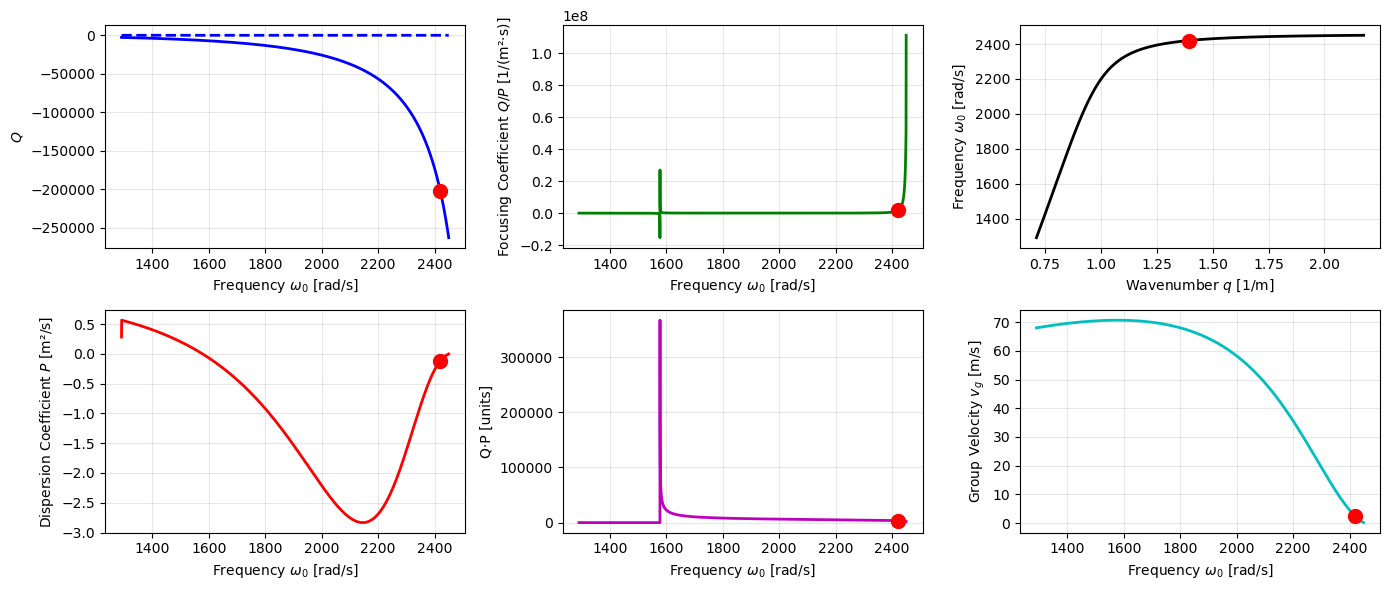

sqrt Q0/(2P0)=  (932.0536483951391-0j)


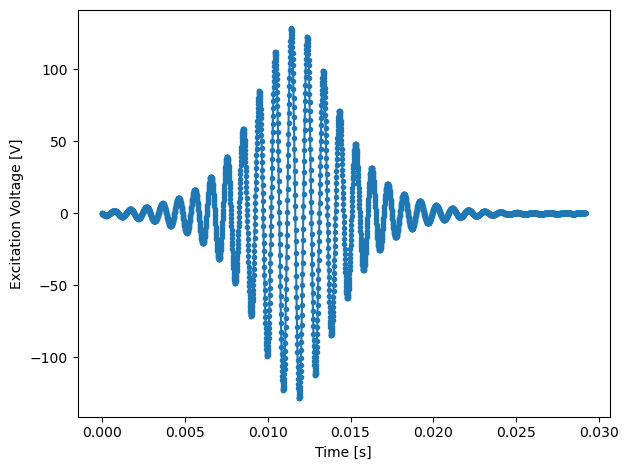

In [119]:
# %%
import importlib
from pyexpat import model
from xml.parsers.expat import model
import numpy as np
from scipy.optimize import fsolve
from scipy.integrate import solve_ivp
import sys
from pathlib import Path
# add Modeling/ to Python path
# project_root = Path.cwd().parents[2] # for notebooks
# project_root = Path(__file__).resolve().parents[3] # for scripts
# sys.path.append(str(project_root))
# project_root = Path.cwd()


def find_project_root(start: Path) -> Path:
    """Find project root that contains the Modeling package."""
    for p in [start, *start.parents]:
        if (p / "Modeling").exists():
            return p
    raise RuntimeError("Could not locate project root containing 'Modeling'.")


project_root = find_project_root(Path.cwd())
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))
from Modeling.models.beam_properties import PiezoBeamParams
from Modeling.models.plotting import animate_field_1d
import matplotlib.pyplot as plt
from Modeling.models.ROM import ROM

import Modeling.models.FE1 as FE1_module
importlib.reload(FE1_module)
FE1 = FE1_module
import Modeling.models.envelope_soliton as envelope_soliton
importlib.reload(envelope_soliton)
HomogenizedModel = envelope_soliton.HomogenizedModel
import numpy as np
from numpy import pi	
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt
from IPython.display import clear_output
from matplotlib import cm, colors
import pandas as pd
from joblib import Parallel, delayed
import matplotlib.pyplot as plt
import pickle
import hashlib

Q = 31
# params_fe = PiezoBeamParams( 
#     hp=0.55e-3, hs=0.51e-3, b=21e-3, w_p=21e-3, w_s=1e-3,
#     Q=Q
# )
j_exc = 30
# epsilon_0 = 8.854e-12
# epsilon_33_T_rel = 2100
params_fe = PiezoBeamParams(
                            hp=0.55e-3, hs=0.51e-3,
                            # hp=0.31e-3, hs=0.607e-3,
                            w_p=21e-3, w_s=1e-3, b=21e-3,
                            d31= -270e-12,eps_r=2100,
							# rho_p=7700,
							# omega_p=2*pi*100, omega_q=2*pi*5000,
							# zeta_dict = zeta_dict
                            n_patches=Q
                            )

fe = FE1.PiezoBeamFE(params_fe,
                      n_el_patch=1, n_el_gap=1
                      )
x_eval = np.linspace(0, params_fe.L_b, 500)

ncycls = 30
delay_factor = 0.4
eps_phi = 0.2
excitation_scale = 0.1
Lj = 6
Lcj = 0.000001
R_c = 1e3
K_c = R_c / Lcj
K_i = R_c/Lj
K_p = 1e-4
save_file_name = f'soliton_FE_hardening_highdamping_longbeam_epsphi006.pkl'

print('L= ', R_c / K_i)
print('Lc= ', R_c / K_c)

ref_scales = params_fe.nondimensional_scales(K_i=K_i, K_c=K_c, R_c=R_c)
hom_params = params_fe.homogenized_parameters(K_c=K_c, R_c=R_c, K_i=K_i)

print(ref_scales)
print(hom_params)



branch = 'acoustic'
# branch = 'optical'
hom_model = HomogenizedModel(
    ref_scales=ref_scales,
    hom_params=hom_params,
    branch= branch
)

peak_focus_data = hom_model.peak_focus()
print('Peak focusing frequency ω₀ =', peak_focus_data['omega0'], 'rad/s',
      '(', peak_focus_data['omega0']/(2*np.pi), 'Hz )')

peak_focus_data = hom_model.focus_point(2420)
omega0 = hom_model.Omega_dim
print("Q/P:", peak_focus_data['Q_over_P'])
v_g, P_func =  hom_model.P_vg_fun_dim()

Q_vals = np.array([hom_model.Q_fun_dim(om0) for om0 in omega0])

P_vals = np.array([P_func(om0) for om0 in omega0])
focusing = Q_vals / P_vals
QP_vals = Q_vals * P_vals

# Find peak focusing frequency

peak_focus_freq = peak_focus_data['omega0']
# peak_focus_freq = 6000
# peak_focus_freq = 4000
# peak_focus_freq = 2861
freq_correction = -1/2*eps_phi**2*peak_focus_data['Q'].real

print('Frequency correction due to nonlinearity:', freq_correction, 'rad/s')
print('Peak focusing frequency ω₀ =', peak_focus_freq, 'rad/s')
print('Peak focusing at frequency f =', peak_focus_freq / (2 * np.pi), 'Hz')
print('Reference frequency:', 1/ref_scales['t0']/2/np.pi, 'Hz', '(', 1/ref_scales['t0'], 'rad/s )')
print('Wavelength at peak focusing:', 2 * np.pi / hom_model.q_fun_dim(peak_focus_freq) * 1e3, 'mm')
print('Q at peak focusing:', peak_focus_data['Q'])
print('P at peak focusing:', peak_focus_data['P'])
print('Q/P at peak focusing:', peak_focus_data['Q_over_P'])
envelope_func, envelope_params = hom_model.envelope(peak_focus_freq, eps_phi=eps_phi)
envelope_params['delay_factor'] = delay_factor
envelope_params['ncycls'] = ncycls
envelope_params['excitation_scale'] = excitation_scale
print('Envelope params:', envelope_params)
fig, ax = plt.subplots(2, 3, figsize=(14, 6))

# Plot Q coefficient
ax[0, 0].plot(omega0, np.real(Q_vals), 'b-', linewidth=2, label='Real Part')
ax[0, 0].plot(omega0, np.imag(Q_vals), 'b--', linewidth=2, label='Imaginary Part')
ax[0, 0].scatter(peak_focus_freq, peak_focus_data['Q'], 
                 color='red', s=100, zorder=5, label=f'Q at Peak {peak_focus_data["Q"]:.2e}')
ax[0, 0].set_xlabel('Frequency $\omega_0$ [rad/s]')
ax[0, 0].set_ylabel('$Q$ ')
ax[0, 0].grid(True, alpha=0.3)
# ax[0, 0].legend()
# Plot P coefficient
ax[1, 0].plot(omega0, P_vals, 'r-', linewidth=2)
ax[1, 0].scatter(peak_focus_freq, peak_focus_data['P'], 
                 color='red', s=100, zorder=5, label=f'P at Peak {peak_focus_data["P"]:.2e}')
ax[1, 0].set_xlabel('Frequency $\omega_0$ [rad/s]')
ax[1, 0].set_ylabel('Dispersion Coefficient $P$ [m²/s]')
ax[1, 0].grid(True, alpha=0.3)

# Plot focusing coefficient Q/P
ax[0, 1].plot(omega0, np.real(focusing), 'g-', linewidth=2)
ax[0, 1].set_xlabel('Frequency $\omega_0$ [rad/s]')
ax[0, 1].set_ylabel('Focusing Coefficient $Q/P$ [1/(m²·s)]')
ax[0, 1].scatter(peak_focus_freq, np.real(peak_focus_data['Q_over_P']), 
                 color='red', s=100, zorder=5, label=f'Peak at {peak_focus_freq:.1f} rad/s')
ax[0, 1].grid(True, alpha=0.3)
# ax[0, 1].legend()

# Plot dispersion relation
ax[0, 2].plot( hom_model.q_fun_dim(omega0)*ref_scales['x0'], omega0, 'k-', linewidth=2)
ax[0, 2].scatter(hom_model.q_fun_dim(peak_focus_freq)*ref_scales['x0'], peak_focus_freq, 
                 color='red', s=100, zorder=5, label='Peak Focusing')
ax[0, 2].set_xlabel('Wavenumber $q$ [1/m]')
ax[0, 2].set_ylabel('Frequency $\omega_0$ [rad/s]')
ax[0, 2].grid(True, alpha=0.3)
# ax[0, 2].legend()

# # Plot Q·P product
# ax[1, 1].plot(omega0, QP_vals, 'm-', linewidth=2)
# ax[1, 1].set_xlabel('Frequency $\omega_0$ [rad/s]')
# ax[1, 1].set_ylabel('Q·P [units]')
# ax[1, 1].grid(True, alpha=0.3)

# Plot group velocity
vg_vals = np.array([v_g(om0) for om0 in omega0])
ax[1, 2].plot(omega0, vg_vals, 'c-', linewidth=2)
ax[1, 2].scatter(peak_focus_freq, envelope_params['vg0'], 
                 color='red', s=100, zorder=5, label=f'v_g at Peak {envelope_params["vg0"]:.2f} m/s')
ax[1, 2].set_xlabel('Frequency $\omega_0$ [rad/s]')
ax[1, 2].set_ylabel('Group Velocity $v_g$ [m/s]')
ax[1, 2].grid(True, alpha=0.3)

ax[1, 1].plot(omega0, vg_vals*np.sqrt(Q_vals/P_vals), 'm-', linewidth=2)
ax[1, 1].scatter(peak_focus_freq, envelope_params['vg0']*np.sqrt(peak_focus_data['Q_over_P']), 
                 color='red', s=100, zorder=5)
ax[1, 1].set_xlabel('Frequency $\omega_0$ [rad/s]')
ax[1, 1].set_ylabel('Q·P [units]')
ax[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


# t_eval = np.linspace(0, ncycls * ref_scales['t0'], ncycls*50)
t_eval = np.linspace(0, ncycls /((peak_focus_freq + freq_correction)/(2*np.pi)), ncycls*100)
v_exc0 =  hom_model.make_v_exc(
    omega0=peak_focus_freq,
    eps_phi=eps_phi,
    t_eval=t_eval,
    t_shift=delay_factor*t_eval[-1]
)


v_exc = lambda t: np.real(v_exc0(t)) * excitation_scale

plt.figure()
plt.plot(t_eval, v_exc(t_eval), '.-')
plt.xlabel('Time [s]')
plt.ylabel('Excitation Voltage [V]')
plt.tight_layout()
plt.show()
# %matplotlib widget

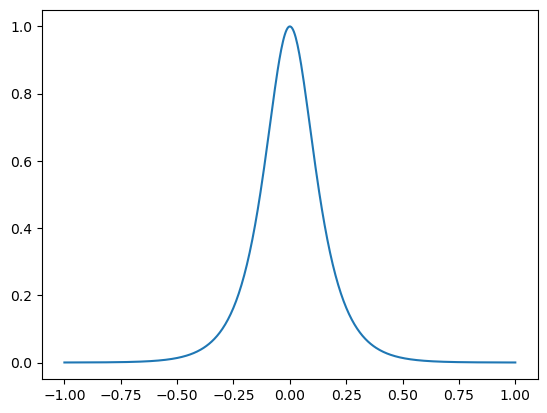

In [120]:
plt.figure()
tt = np.linspace(-1,1, 500)
plt.plot(tt, 1/np.cosh(tt*10))

In [121]:
peak_focus_data['Q'].real

np.float64(-202068.34627875919)

In [122]:

# %% Solve the system with soliton excitation
ode = fe.build_ode_system(
    j_exc=j_exc,
    K_c=K_c,
    K_i=K_i,
    K_p=K_p,
    v_exc=v_exc
)

ndof = ode.M.shape[0]
x0 = np.zeros(ndof)
x_dot0 = np.zeros(ndof)

result = FE1.solve_newmark(
    ode=ode,
    dt=t_eval[1]-t_eval[0],
    t_end=t_eval[-1],
    beta=0.25,
    gamma=0.5,
    newton_tol=1e-8,
    newton_maxiter=8,
    x0=x0,
    x_dot0=x_dot0
)

# Extract results from dictionary
t = result['t']
w = result['u']
w_dot = result['u_dot']
w_ddot = result['u_ddot']
q = result['q']
v = result['v']
spec_td = result['spectral']


result['envelope_params'] = envelope_params
result['K_c'] = K_c
result['K_i'] = K_i
result['K_p'] = K_p

# Create results directory and save
results_dir = Path('./results')
results_dir.mkdir(parents=True, exist_ok=True)

# Avoid overwriting existing results by auto-incrementing the filename.
save_path = results_dir / save_file_name
if save_path.exists():
    stem = save_path.stem
    suffix = save_path.suffix
    counter = 1
    while True:
        candidate = results_dir / f"{stem}_{counter}{suffix}"
        if not candidate.exists():
            save_path = candidate
            break
        counter += 1

with open(save_path, 'wb') as f:
    pickle.dump(result, f)

print(f"Results saved to {save_path}")



Newmark Integration: 100%|██████████| 2999/2999 [00:02<00:00, 1083.76step/s]

X shape: (3000,) Y shape: (3000, 63) freq shape: (3000,) veloc shape: (3000, 63)
Results saved to results\soliton_FE_hardening_highdamping_longbeam_epsphi006_6.pkl
